In [3]:
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt

In [35]:
def delta(S, T, r, K, sigma, option_type:str='call'):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T)/(sigma*np.sqrt(T))
    if option_type == 'call':
        return norm.cdf(d1)
    elif option_type == 'put':
        return norm.cdf(d1)-1

def gamma(S, T, r, K, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T)/(sigma*np.sqrt(T))
    return norm.pdf(d1)/(S*sigma*np.sqrt(T))

def vega(S, T, r, K, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T)/(sigma*np.sqrt(T))
    return S*norm.pdf(d1)*np.sqrt(T)

def theta(S, T, r, K, sigma, option_type:str='call'):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T)/(sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if option_type == 'call':
        return -r*K*norm.cdf(d2)*np.exp(-r*T) - (sigma*S*norm.pdf(d1))/(2*np.sqrt(T))
    elif option_type == 'put':
        return r*K*norm.cdf(-d2)*np.exp(-r*T) - (sigma*S*norm.pdf(d1))/(2*np.sqrt(T))

def rho(S, T, r, K, sigma, option_type:str='call'):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T)/(sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if option_type == 'call':
        return K*T*np.exp(-r*T)*norm.cdf(d2)
    elif option_type == 'put':
        return -K*T*np.exp(-r*T)*norm.cdf(-d2)

In [19]:
# Fixing strike and expiry
S = np.linspace(50,150,500)

K = 100
T = 1
r = 0.05
sigma = 0.2

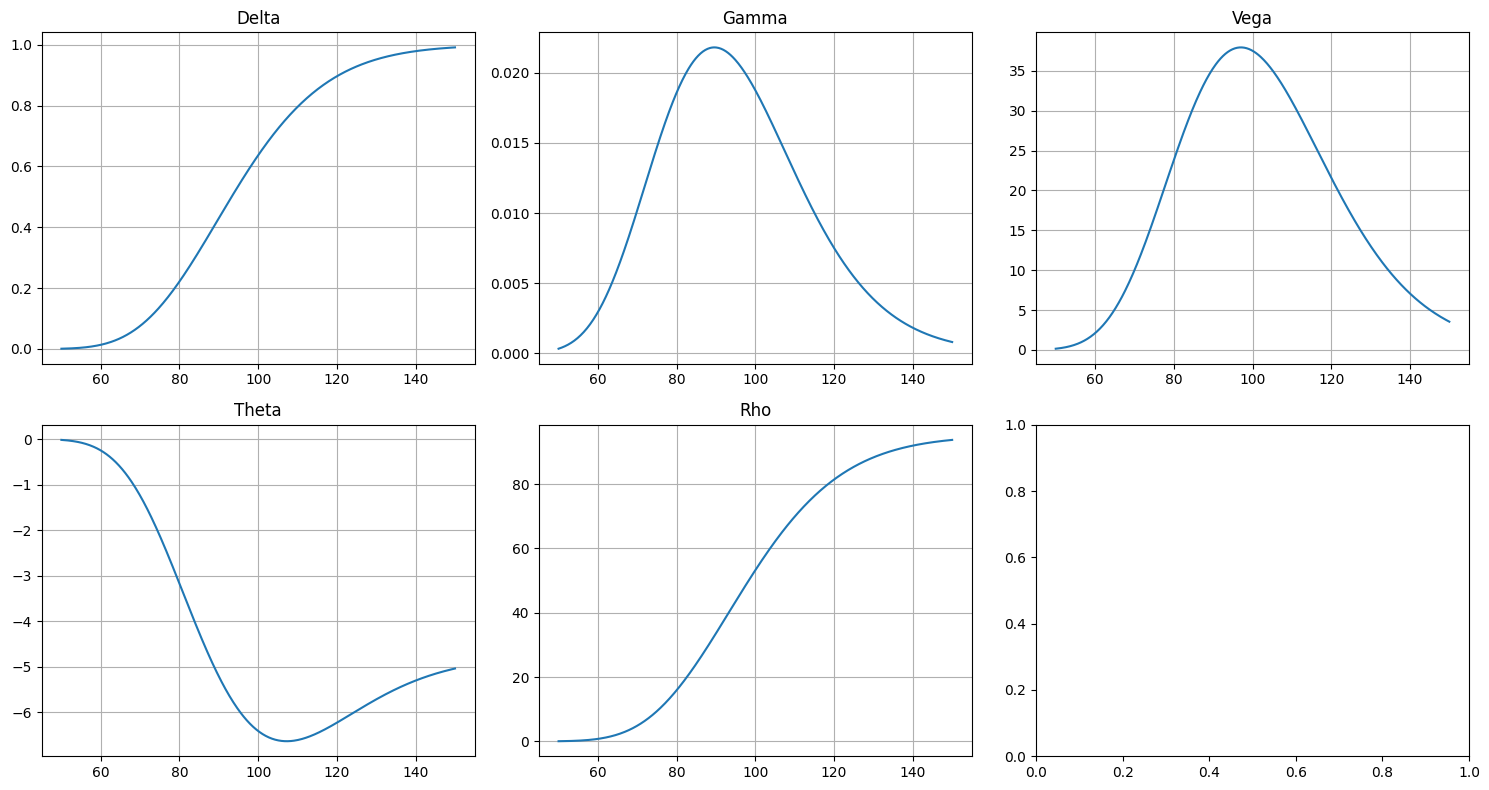

In [20]:
fig, ax = plt.subplots(2,3, figsize=(15,8))

greeks = [
    ('Delta', delta),
    ('Gamma', gamma),
    ('Vega', vega),
    ('Theta', theta),
    ('Rho', rho)
]

for axis, (name, greek) in zip(ax.flatten(), greeks):

    values = [greek(s,T,r,K,sigma) for s in S]

    axis.plot(S, values)
    axis.set_title(name)
    axis.grid()

plt.tight_layout()